# Import Libraries
- yfinance as raw data
- torch as neural network & learning model
- pandas for dataframes 
- matplotlib for visualization
- sklearn for data preprocessing


In [403]:
import yfinance as yf

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

## Checking Cuda Viability

In [404]:
# Printing if cuda is possible
print(torch.cuda.is_available())

# Printing the cuda device
print(torch.cuda.get_device_name(0))
print(torch.cuda.device_count())

# Checking if cuda is activated
print(torch.get_default_device())

True
NVIDIA GeForce RTX 5070 Laptop GPU
1
cuda:0


# Importing Data from YFinance

In [405]:
import yfinance as yf

tickers = ['AAPL', 'GOOG', 'MSFT', 'NVDA', 'JPM', 'GS', 'XOM', 'CAT', 'GE', 'WMT']

In [406]:
# Defining transformation functions

# Simple Moving Average

def calculate_moving_average(dataframe, window):
    col_name = "".join(filter(str.isdigit, str(window)))

    dataframe[f"sma_{col_name}"] = (
        dataframe['Close']
        .rolling(window = window, min_periods = 1)
        .mean()
    )

    return dataframe; 

# RSI Calculations

def calculate_rsi(dataframe, window_size): 
    temp_df = pd.DataFrame({'Difference': dataframe['Close'].diff()})

    temp_df['Gain'] = temp_df['Difference'].clip(lower = 0)
    temp_df['Loss'] = temp_df['Difference'].clip(upper = 0).abs()

    temp_df['Avg_Gain'] = temp_df['Gain'].rolling(window = window_size, min_periods = 1).mean()
    temp_df['Avg_Loss'] = temp_df['Loss'].rolling(window = window_size, min_periods = 1).mean()

    rs = temp_df['Avg_Gain'] / temp_df['Avg_Loss']

    col_name = "".join(filter(str.isdigit, str(window_size)))

    dataframe[f'rsi_{col_name}'] = 100 - (100 / (1 + rs))

    return dataframe

def calculate_ewm_rsi(dataframe, window_size): 
    temp_df = pd.DataFrame({'Difference': dataframe['Close'].diff()})

    temp_df['Gain'] = temp_df['Difference'].clip(lower = 0)
    temp_df['Loss'] = temp_df['Difference'].clip(upper = 0).abs()

    temp_df['Avg_Gain'] = temp_df['Gain'].ewm(span = window_size, adjust = False).mean()
    
    temp_df['Avg_Loss'] = temp_df['Loss'].ewm(span = window_size, adjust = False).mean()

    rs = temp_df['Avg_Gain'] / temp_df['Avg_Loss']

    col_name = "".join(filter(str.isdigit, str(window_size)))

    dataframe[f'ewm_rsi_{col_name}'] = 100 - (100 / (1 + rs))

    return dataframe

# Volatility & Bollinger Bands
def calculate_volatility(dataframe, window_size): 
    col_name = "".join(filter(str.isdigit, str(window_size)))

    dataframe[f'volatility_{col_name}'] = dataframe['Close'].rolling(window = window_size, min_periods = 2).std()

    return dataframe

def calculate_bollinger_bands(dataframe, window_size, num_std): 
    roll_window = dataframe['Close'].rolling(window = window_size, min_periods = 2)

    mid_band = roll_window.mean()
    std_dev = roll_window.std()

    col_id = "".join(filter(str.isdigit, str(window_size)))

    dataframe[f'bollinger_band_mid_{col_id}'] = mid_band
    dataframe[f'bollinger_band_upper_{col_id}'] = mid_band + (num_std * std_dev)
    dataframe[f'bollinger_band_lower_{col_id}'] = mid_band - (num_std * std_dev)

    return dataframe

def transform(dataframe): 
    df = dataframe.sort_index().copy()
    
    df = calculate_moving_average(dataframe, 20)
    df = calculate_moving_average(dataframe, 50)
    df = calculate_moving_average(dataframe, 100)
    df = calculate_rsi(dataframe, 14)
    df = calculate_ewm_rsi(dataframe, 14)
    df = calculate_volatility(dataframe, 30)
    df = calculate_bollinger_bands(dataframe, 30, 2)

    return df

# Gold Data Preparation
### Main Adjustments: 
- Scaling features into pct_change values
- Clipping outliers after adjustments w/ np.percentile
- MinMaxScaler > StandardScaler
- Bollinger Band % instead of price based
- Encoding days of the week
- Dropping N/A & removing min_period values

### Reasoning: 
- Scaling features instead of using raw data allows the model to be trained based on scaling factors instead of hard values. These hard values make it hard to use MinMaxScaler & does not allow the LSTM model to learn from the data as it is ever increasing
- Outliers can force compress other vaules during scaling. 
- MinMaxScaler 

In [407]:
def transform_gold(dataframe): 
    df = dataframe.copy()
    
    trimmed_df = df.drop(['High', 'Low', 'Open'], axis=1)
    
    # Assest that values match
    expected_columns = ['Close', 'Volume', 'sma_20', 'sma_50', 'sma_100',
                        'bollinger_band_upper_30', 'bollinger_band_lower_30',
                        'bollinger_band_mid_30', 'rsi_14', 'ewm_rsi_14', 'volatility_30']
    
    columns_to_drop = ['Close', 'Volume', 'sma_20', 'sma_50', 'sma_100', 'volatility_30', 
                        'day_of_week']
    
    is_match = set(trimmed_df.columns) == set(expected_columns)
    
    # Calculating target
    if not is_match:
        print("Columns do not match expected columns")
        return df
    
    trimmed_df['target'] = (trimmed_df['Close'] - trimmed_df['Close'].shift(1)) / trimmed_df['Close'].shift(1)
    
    target_lower = trimmed_df["target"].quantile(0.01)
    target_upper = trimmed_df["target"].quantile(0.99)
    
    trimmed_df["target"] = trimmed_df["target"].clip(lower=target_lower, upper=target_upper)
    
    # Calculating Price Relative MA's
    trimmed_df['close_to_sma_20'] = (trimmed_df['Close'] / trimmed_df['sma_20']) - 1
    trimmed_df['close_to_sma_50'] = (trimmed_df['Close'] / trimmed_df['sma_50']) - 1
    
    # Calculating Bollinger Bands
    trimmed_df["pc_b"] = (trimmed_df['Close'] - trimmed_df["bollinger_band_lower_30"]) / (trimmed_df['bollinger_band_upper_30'] - trimmed_df['bollinger_band_lower_30'])
    trimmed_df["pc_b"] = trimmed_df["pc_b"].clip(lower=0, upper=1)
    
    trimmed_df['bb_width'] = (trimmed_df['bollinger_band_upper_30'] - trimmed_df['bollinger_band_lower_30']) / trimmed_df['bollinger_band_mid_30']
    trimmed_df = trimmed_df.drop(columns=['bollinger_band_upper_30', 'bollinger_band_lower_30', 'bollinger_band_mid_30'])
    
    # Calculating RSI
    threshold = 0.85
    correlation = trimmed_df[['rsi_14', 'ewm_rsi_14']].corr()
    
    corr_value = correlation.iloc[0, 1]
    
    if abs(corr_value) > threshold: 
        columns_to_drop.append('ewm_rsi_14')
        print(f"RSI Correlation: {corr_value:.3f} - Dropping ewm_rsi_14 {abs(corr_value)} > threshold (0.85)")
        
    # Calculating Volatility
    pct_returns_series = trimmed_df['Close'].pct_change()
    trimmed_df['pct_volatility_30'] = pct_returns_series.rolling(window=30, min_periods=30).std()
    
    # Calculating Volume
    volume_pct_change = trimmed_df["Volume"].pct_change()
    trimmed_df['volume_pct_change'] = volume_pct_change
    
    vol_lower = trimmed_df['volume_pct_change'].quantile(0.01)
    vol_upper = trimmed_df['volume_pct_change'].quantile(0.99)
    
    trimmed_df['volume_pct_change'] = trimmed_df['volume_pct_change'].clip(lower=vol_lower, upper=vol_upper)
    
    # Calculating Cyclical Day of the Week
    trimmed_df['day_of_week'] = trimmed_df.index.dayofweek
    
    trimmed_df['day_sin'] = np.sin(2 * np.pi * trimmed_df['day_of_week'] / 5)
    trimmed_df['day_cos'] = np.cos(2 * np.pi * trimmed_df['day_of_week'] / 5)
    
    # Cleaning up 
    processed_df = trimmed_df.drop(columns=columns_to_drop)
    
    processed_df = processed_df.dropna()
    
    return processed_df

# Interjection
- After round 1 it has been determined that more data is required, both in years and the number of tickers provided
- This will require a function to iterate through the downloading process and finally concatenate all values into one large sequence

In [408]:
def create_sequence(features, target, window_size): 
    X = []
    y = []
    
    for i in range (len(features) - window_size): 
        window = features[i: i + window_size]
        label = target[i + window_size]
        
        X.append(window)
        y.append(label)
    
    return np.array(X), np.array(y)

In [409]:
def build_dataset(tickers, window_size): 
    ticker_data = {}
    X_train_all = []
    scaler = MinMaxScaler()
    
    for t in tickers: 
        df = yf.download(t, period="max", interval="1d")
        if isinstance(df.columns, pd.MultiIndex): 
            df.columns = df.columns.droplevel(1)
        
        print(f"Columns for {t}: {df.columns}")
        
        silver_df = transform(df)
        gold_df = transform_gold(silver_df)
        
        if gold_df is None or gold_df.empty: 
            print(f"{t} failed. Skipping...")
            continue
        
        train_end = int(len(gold_df) * .70)
        val_end = int(len(gold_df) * .85)
        
        train_df = gold_df.iloc[:train_end]
        val_df = gold_df.iloc[train_end:val_end]
        test_df = gold_df.iloc[val_end:]
        
        X_train = train_df.drop(columns=['target'])
        y_train = train_df['target'].values
        
        X_val = val_df.drop(columns=['target'])
        y_val = val_df['target'].values
        
        X_test = test_df.drop(columns=['target'])      
        y_test = test_df['target'].values
        
        ticker_data[t] = {
            'X_train': X_train.to_numpy(), 'X_val': X_val.to_numpy(), 'X_test': X_test.to_numpy(),
            'y_train': y_train, 'y_val': y_val, 'y_test': y_test
        }
        
        X_train_all.append(X_train .to_numpy())
    
    X_train = np.concatenate(X_train_all)
    scaler.fit(X_train)
    
    X_train_seqs, X_val_seqs, X_test_seqs = [], [], []
    y_train_seqs, y_val_seqs, y_test_seqs = [], [], []
    
    for t, t_data in ticker_data.items(): 
        t_data['X_train'] = scaler.transform(t_data['X_train'])
        t_data['X_val'] = scaler.transform(t_data['X_val'])
        t_data['X_test'] = scaler.transform(t_data['X_test'])
        
        X_train_seq, y_train_seq = create_sequence(t_data['X_train'], t_data['y_train'], window_size)
        X_val_seq, y_val_seq = create_sequence(t_data["X_val"], t_data['y_val'], window_size)
        X_test_seq, y_test_seq = create_sequence(t_data['X_test'], t_data['y_test'], window_size)
        
        X_train_seqs.append(X_train_seq); X_val_seqs.append(X_val_seq); X_test_seqs.append(X_test_seq)
        y_train_seqs.append(y_train_seq); y_val_seqs.append(y_val_seq); y_test_seqs.append(y_test_seq)
    
    X_train = np.concatenate(X_train_seqs); X_val = np.concatenate(X_val_seqs); X_test = np.concatenate(X_test_seqs)
    y_train = np.concatenate(y_train_seqs); y_val = np.concatenate(y_val_seqs); y_test = np.concatenate(y_test_seqs)
    
    return X_train, y_train, X_val, y_val, X_test, y_test, scaler

# Splitting & Scaling The Data
### Changes From Norm: 
- Because stock data relies on inline data because of datetime indexing, splitting will be done without tts
- Splitting will be 70/15/15 for train/validate/test
- Will use MinMaxScaler 

In [410]:
X_train, y_train, X_validate, y_validate, X_test, y_test, scaler = build_dataset(tickers, 20)

[*********************100%***********************]  1 of 1 completed


Columns for AAPL: Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')
RSI Correlation: 0.880 - Dropping ewm_rsi_14 0.8803473081014368 > threshold (0.85)


[*********************100%***********************]  1 of 1 completed


Columns for GOOG: Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')
RSI Correlation: 0.869 - Dropping ewm_rsi_14 0.8687435245782835 > threshold (0.85)


[*********************100%***********************]  1 of 1 completed


...

Columns for CAT: Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')
RSI Correlation: 0.869 - Dropping ewm_rsi_14 0.8690584125821037 > threshold (0.85)


[*********************100%***********************]  1 of 1 completed


Columns for GE: Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')
RSI Correlation: 0.870 - Dropping ewm_rsi_14 0.8697391489122176 > threshold (0.85)


[*********************100%***********************]  1 of 1 completed

Columns for WMT: Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')
RSI Correlation: 0.871 - Dropping ewm_rsi_14 0.870722933184727 > threshold (0.85)


# Torchify It!

In [411]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_validate_tensor = torch.tensor(X_validate, dtype=torch.float32)
y_validate_tensor = torch.tensor(y_validate, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
validate_dataset = TensorDataset(X_validate_tensor, y_validate_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
validate_loader = DataLoader(validate_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [412]:
print(X_train_tensor.shape)

torch.Size([79880, 20, 9])


# Creating the Model

In [413]:
INPUT_SIZE = 9
HIDDEN_SIZE = 64 # 4-8 times the size of your input size
NUM_LAYERS = 2 # Stacked LSTM layers
DROPOUT = 0.5

class StockLSTM(nn.Module): 
    def __init__(self, input_size, hidden_size, num_layers, dropout): 
        super(StockLSTM, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout = dropout
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, dropout=dropout if num_layers > 1 else 0.0, batch_first=True)
        self.regressor = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout), 
            nn.Linear(32, 1)
        )
        
        for name, param in self.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)
                total = param.size(0)
                quarter = total // 4
                param.data[quarter:quarter*2] = 1.0
        
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_time_step = lstm_out[:, -1, :]
        
        prediction = self.regressor(last_time_step)
        
        return prediction

# Training Loop

In [414]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Ensure cuda usage

In [415]:
def calculate_mad(tensor): 
    mean = torch.mean(tensor.float())
    abs_deviation = torch.abs(tensor - mean)
    
    mad = torch.mean(abs_deviation)
    
    print(mad)
    return mad

In [416]:
model = StockLSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT)
criterion = nn.HuberLoss(delta = 0.04)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.001)
EPOCHS = 10

model.to(device)

StockLSTM(
  (lstm): LSTM(9, 64, num_layers=2, batch_first=True, dropout=0.5)
  (regressor): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [417]:
for name, param in model.named_parameters():
    if 'bias_ih' in name:
        total = param.size(0)
        quarter = total // 4
        forget_slice = param.data[quarter:quarter*2]
        print(f"{name} forget gate mean: {forget_slice.mean():.4f}")

lstm.bias_ih_l0 forget gate mean: 1.0000
lstm.bias_ih_l1 forget gate mean: 1.0000


In [418]:
model.eval()
with torch.no_grad():
    sample_X = next(iter(train_loader))[0].to(device)
    sample_pred = model(sample_X)
    print(sample_pred.squeeze()[:10])

tensor([-0.0450, -0.0466, -0.0434, -0.0423, -0.0457, -0.0494, -0.0470, -0.0418,
        -0.0399, -0.0458], device='cuda:0')


In [419]:
train_losses = []
val_losses = []

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

print(f"Target STD: {y_train.std()}")

for epoch in range(EPOCHS): 
    model.train()
    train_loss = 0.0
    
    # Epoch Train
    for batch_X, batch_y in train_loader: 
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        
        prediction = model(batch_X)
        loss = criterion(prediction.squeeze(), batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
    
    # Validation Phase
    model.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for batch_X, batch_y in validate_loader: 
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            prediction = model(batch_X)
            loss = criterion(prediction.squeeze(), batch_y.squeeze())
            val_loss += loss.item()
            
    # Epoch Summary
    avg_train = train_loss / len(train_loader)
    avg_val = val_loss / len(validate_loader)
    
    scheduler.step(avg_val)
    
    train_losses.append(avg_train)
    val_losses.append(avg_val)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train:.6f} | Val Loss: {avg_val:.6f}")
    print(f"Current LR: {optimizer.param_groups[0]['lr']}")
    

Target STD: 0.019852081721580105
Epoch 1/10 | Train Loss: 0.000229 | Val Loss: 0.000137
Current LR: 0.001
Epoch 2/10 | Train Loss: 0.000187 | Val Loss: 0.000137
Current LR: 0.001
Epoch 3/10 | Train Loss: 0.000187 | Val Loss: 0.000137
Current LR: 0.001
Epoch 4/10 | Train Loss: 0.000187 | Val Loss: 0.000137
Current LR: 0.001
Epoch 5/10 | Train Loss: 0.000187 | Val Loss: 0.000137
Current LR: 0.0005
Epoch 6/10 | Train Loss: 0.000187 | Val Loss: 0.000137
Current LR: 0.0005
Epoch 7/10 | Train Loss: 0.000187 | Val Loss: 0.000137
Current LR: 0.0005
Epoch 8/10 | Train Loss: 0.000187 | Val Loss: 0.000137
Current LR: 0.0005
Epoch 9/10 | Train Loss: 0.000187 | Val Loss: 0.000137
Current LR: 0.0005
Epoch 10/10 | Train Loss: 0.000187 | Val Loss: 0.000137
Current LR: 0.00025


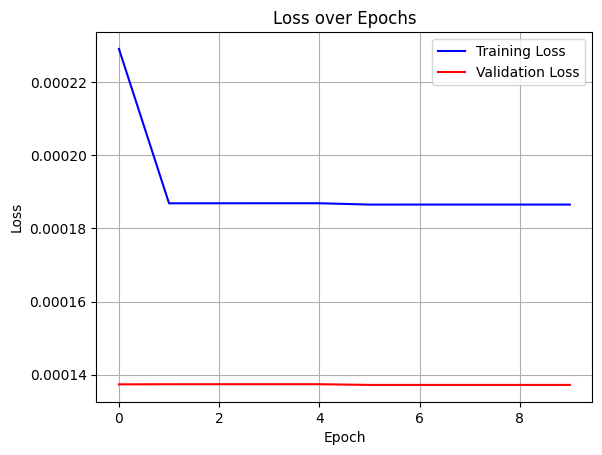

In [420]:
plt.plot(train_losses, label="Training Loss", color="blue")
plt.plot(val_losses, label="Validation Loss", color="Red")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.grid(True)
plt.legend()
plt.show()

## Evaluation 

In [421]:
model.eval()

all_predictions = []
all_true = []

with torch.no_grad(): 
    for batch_X, batch_y in test_loader: 
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        prediction = model(batch_X)
        
        numpy_pred, numpy_y = prediction.detach(), batch_y.detach()
        
        all_predictions.append(numpy_pred.squeeze().cpu().numpy())
        all_true.append(batch_y.cpu().numpy())
        
all_predictions = np.concatenate(all_predictions, axis=0)
all_true = np.concatenate(all_true, axis=0)

In [422]:
def directional_accuracy(y_true, y_pred):
    true_direction = np.sign(y_true)
    pred_direction = np.sign(y_pred)
    
    return (true_direction == pred_direction).mean()

In [423]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse  = mean_squared_error(all_true, all_predictions)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(all_true, all_predictions)
da   = directional_accuracy(all_true, all_predictions)

print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"Directional Accuracy: {da:.2%}")

RMSE: 0.018029
MAE:  0.013143
Directional Accuracy: 52.75%


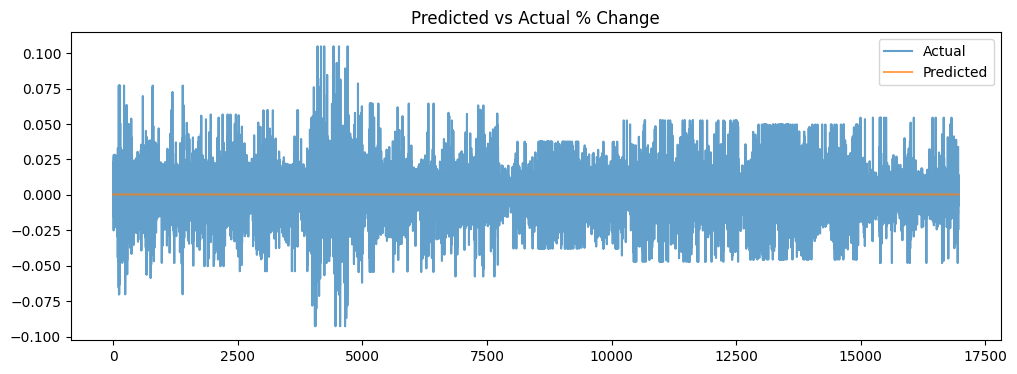

In [424]:
plt.figure(figsize=(12, 4))
plt.plot(all_true, label='Actual', alpha=0.7)
plt.plot(all_predictions, label='Predicted', alpha=0.7)
plt.legend()
plt.title('Predicted vs Actual % Change')
plt.show()

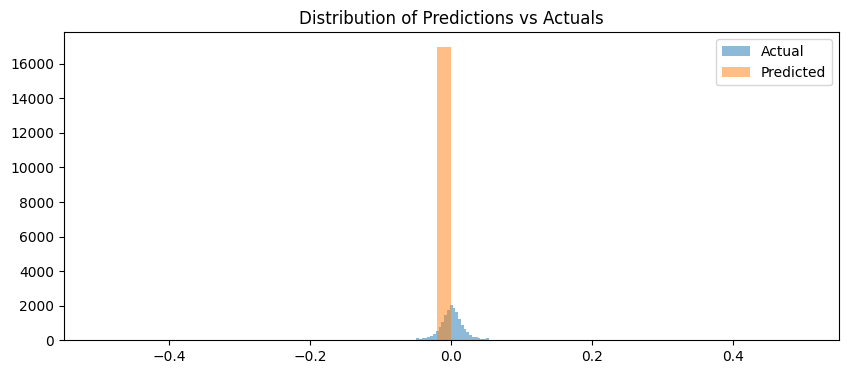

In [425]:
plt.figure(figsize=(10, 4))
plt.hist(all_true, bins=50, alpha=0.5, label='Actual')
plt.hist(all_predictions, bins=50, alpha=0.5, label='Predicted')
plt.legend()
plt.title('Distribution of Predictions vs Actuals')
plt.show()

In [426]:
print(f"Prediction mean: {all_predictions.mean():.6f}")
print(f"Prediction std:  {all_predictions.std():.6f}")
print(f"Actual mean:     {all_true.mean():.6f}")
print(f"Actual std:      {all_true.std():.6f}")

Prediction mean: 0.000311
Prediction std:  0.000000
Actual mean:     0.001043
Actual std:      0.018014


In [427]:
print(f"Current LR: {optimizer.param_groups[0]['lr']}")

Current LR: 0.00025
